# XGBoost Model for Energy Price in Spain

## Why XGBoost

XGBoost (eXtreme Gradient Boosting) is a powerful, scalable machine learning algorithm based on gradient boosting. It builds decision trees sequentially, where each tree corrects the errors of the previous one, optimizing for a custom loss function.

XGBoost can be effectively applied to time series analysis, including energy price forecasting, by treating the problem as a supervised learning task. Instead of directly modeling the temporal dependencies, XGBoost can leverage lagged features, rolling statistics (e.g. moving averages), and other relevant external factors (e.g. energy generation and weather) as input features. Its flexibility and ability to handle nonlinear relationships make it well-suited for energy price forecasting.

The table below highlights how XGBoost is well-suited to predicting price demand compared with other non-neural-network-based machine learning methods:

| Feature                         | XGBoost | Linear Regression | Random Forest | Decision Tree | SVR (Support Vector Regression) |
|---------------------------------|---------|-------------------|--------------|--------------|--------------------------|
| Handles Non-Linearity           | ✅   | ❌             | ✅        | ✅        | ✅  (with Kernel)     |
| Captures Feature Interactions   | ✅   | ❌             | ✅        | ❌         | ✅  (with Kernel)     |
| Manages Missing/Noisy Data      | ✅   | ❌             | ✅        | ❌         | ❌                     |
| Computational Efficiency        | ✅  | ✅          | ❌     | ✅       | ❌                   |
| Avoids Overfitting             | ✅ Regularisation | ❌ | ✅ Less Efficient | ❌  | ✅ Regularisation        |
| Sequential Learning             | ✅   | ❌             | ❌         | ❌         | ❌                    |  
| Suitable for Large Datasets     | ✅   | ✅          | ✅        | ✅        | ❌  (Slow for Large Data) |



## Multi-Output XGBoost

The model needs to be able to make 24 hourly predictions for the following day at noon. This can be achieved using:
- **One model per hour** : 24 different models, one for each hour
    - Pros : Specializes in hour-specific patterns, improving accuracy.
    - Cons : Computationally expensive and lacks inter-hour dependency learning.
- **Recursive Autoregressive Approach** : predict one hour at a time, feeding predictions back as inputs for future hours
    - Pros : Captures sequential dependencies dynamically with a single model.
    - Cons : Errors compound over time, potentially degrading later predictions.

Therefore, a one model per hour model will be used. The compounding errors of the recursive autoregressive approach will become too large since 36 time steps need to be predicted.

## Data Exploration

This section imports the weather dataset and explores the daily gas price and the energy generation data.

The energy price dataset has already been explored in [SARIMA_price.ipynb](SARIMA_price.ipynb).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d
import geopandas as gpd
import shapely.geometry
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import shap
import joblib

Import weather data and duplicate all steps to handle missing data and formatting as was done in [xgboost_demand.ipynb](xgboost_demand.ipynb).

In [2]:
from datetime import timedelta

cities = ['barcelona', 'seville', 'valencia', 'bilbao']

weather_df = pd.read_csv('data/weather_data_madrid.csv')

for city in cities:
    weather_df_temp = pd.read_csv(f'data/weather_data_{city}.csv')
    weather_df = pd.concat([weather_df, weather_df_temp])

weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')

# Remove duplicate rows
weather_df = weather_df.reset_index().drop_duplicates(subset=['datetime', 'name'], 
                                                        keep='first')

# Add missing rows by copying the previous row's data
prev_datetime = weather_df['datetime'].iloc[0]

new_rows = []
for i in range(1, len(weather_df)):
    current_datetime = weather_df['datetime'].iloc[i]

    if weather_df['name'].iloc[i] == weather_df['name'].iloc[i - 1]:

        while prev_datetime + timedelta(hours=1) < current_datetime:
            new_row = weather_df.iloc[i - 1].copy()
            new_row['datetime'] = prev_datetime + timedelta(hours=1)
            new_rows.append(new_row)
            prev_datetime += timedelta(hours=1)
    
    prev_datetime = current_datetime

if new_rows:
    weather_df = pd.concat([weather_df, pd.DataFrame(new_rows)], ignore_index=True)

weather_df = weather_df.sort_values(by=['name', 'datetime']).reset_index(drop=True)

# Remove non-numerical or empty columns
weather_df = weather_df.drop(['preciptype', 'severerisk', 'conditions', 'icon', 'stations'], axis=1)

weather_df = weather_df.ffill()

# Remove columns with perfect correlation to other columns
weather_df = weather_df.drop(columns=['solarenergy', 'uvindex'])

Import and explore daily gas price data. The plot of daily gas price shows similar trends to the energy price. For example, the increase in price during the 2022-2023 period is consistent and suggests that gas price will be a useful exogenous variable.

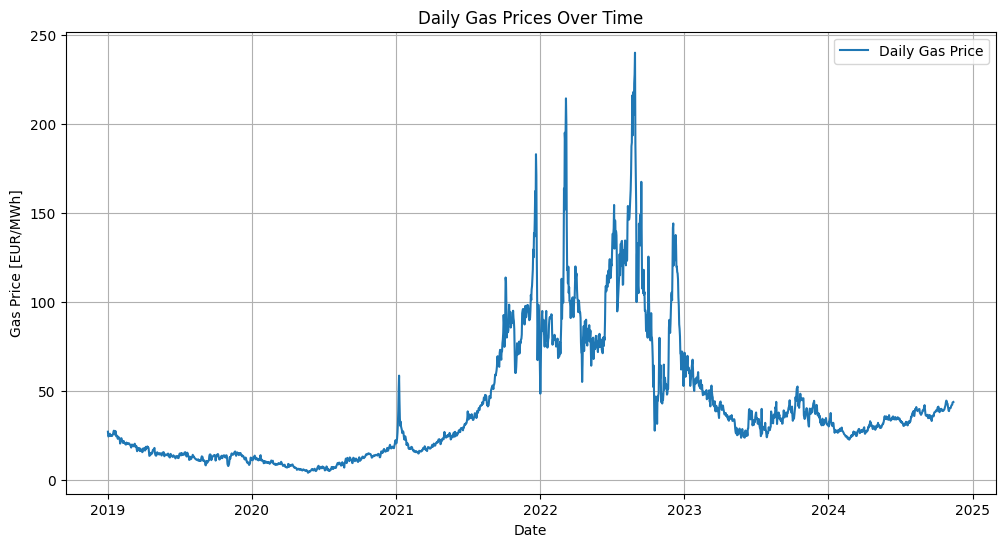

In [3]:
gas_df = pd.read_csv('data/gasPriceData.csv')
gas_df['Trading day'] = pd.to_datetime(gas_df['Trading day'], errors='coerce').dt.date

plt.figure(figsize=(12, 6))
plt.plot(gas_df["Trading day"], gas_df["MIBGAS Daily Price [EUR/MWh]"], linestyle="-", label="Daily Gas Price")
plt.xlabel("Date")
plt.ylabel("Gas Price [EUR/MWh]")
plt.title("Daily Gas Prices Over Time")
plt.legend()
plt.grid(True)
plt.show()

Import and explore hourly energy generation data for various energy sources.

In [4]:
generation_df = pd.read_csv('data/energyGeneration.csv')
generation_df['datetime'] = pd.to_datetime(generation_df['datetime'], errors='coerce')
generation_df.describe()

,datetime,Biomass,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,Geothermal,...,Hydro Water Reservoir,Marine,Nuclear,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore,Other,Hydro Pumped Storage Generation
count,43849,43849.00000,43849.0,43849.0,43849.000000,43849.000000,43849.000000,43849.0,43849.0,43849.0,...,43849.000000,43849.0,43849.000000,43849.000000,43849.000000,43849.000000,43849.0,43849.000000,43849.000000,43849.000000
mean,2022-05-02 12:00:00,420.53739,0.0,0.0,6791.947867,581.726014,121.239663,0.0,0.0,0.0,...,2394.754453,0.0,6222.512760,91.523022,3660.541517,254.717827,0.0,6690.128464,33.731556,322.443568
min,2019-11-01 00:00:00,84.00000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,144.000000,0.0,3196.000000,44.000000,0.000000,88.000000,0.0,176.000000,0.000000,0.000000
25%,2021-01-30 18:00:00,369.00000,0.0,0.0,4300.000000,304.000000,52.000000,0.0,0.0,0.0,...,1047.000000,0.0,5696.000000,80.000000,64.000000,228.000000,0.0,3600.000000,12.000000,0.000000
50%,2022-05-02 12:00:00,428.00000,0.0,0.0,6124.000000,480.000000,116.000000,0.0,0.0,0.0,...,2016.000000,0.0,6680.000000,92.000000,668.000000,260.000000,0.0,5984.000000,44.000000,0.000000
75%,2023-08-02 06:00:00,482.00000,0.0,0.0,8756.000000,773.000000,180.000000,0.0,0.0,0.0,...,3396.000000,0.0,6992.000000,102.000000,6584.000000,288.000000,0.0,9199.000000,55.000000,236.000000
max,2024-11-01 00:00:00,609.00000,0.0,0.0,20454.000000,2370.000000,321.000000,0.0,0.0,0.0,...,9975.000000,0.0,7136.000000,131.000000,21332.000000,349.000000,0.0,20684.000000,85.000000,4068.000000
std,NaN,84.25044,0.0,0.0,3270.625389,351.990900,77.419416,0.0,0.0,0.0,...,1641.845387,0.0,933.278468,13.381382,4883.455710,42.650276,0.0,3873.625646,22.734807,678.601518


Remove all columns with no data. All remaining columns have a count of 43849, meaning there is no missing data

In [5]:
generation_df = generation_df.drop(['Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Oil shale', 'Fossil Peat', 'Geothermal', 'Marine', 'Wind Offshore'], axis=1)

generation_df.describe()

,datetime,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Hydro Pumped Storage Consumption,Hydro Run-of-river and poundage,Hydro Water Reservoir,Nuclear,Other renewable,Solar,Waste,Wind Onshore,Other,Hydro Pumped Storage Generation
count,43849,43849.00000,43849.000000,43849.000000,43849.000000,43849.000000,43849.00000,43849.000000,43849.000000,43849.000000,43849.000000,43849.000000,43849.000000,43849.000000,43849.000000
mean,2022-05-02 12:00:00,420.53739,6791.947867,581.726014,121.239663,750.200757,962.09259,2394.754453,6222.512760,91.523022,3660.541517,254.717827,6690.128464,33.731556,322.443568
min,2019-11-01 00:00:00,84.00000,0.000000,0.000000,0.000000,0.000000,252.00000,144.000000,3196.000000,44.000000,0.000000,88.000000,176.000000,0.000000,0.000000
25%,2021-01-30 18:00:00,369.00000,4300.000000,304.000000,52.000000,0.000000,664.00000,1047.000000,5696.000000,80.000000,64.000000,228.000000,3600.000000,12.000000,0.000000
50%,2022-05-02 12:00:00,428.00000,6124.000000,480.000000,116.000000,239.000000,939.00000,2016.000000,6680.000000,92.000000,668.000000,260.000000,5984.000000,44.000000,0.000000
75%,2023-08-02 06:00:00,482.00000,8756.000000,773.000000,180.000000,1156.000000,1206.00000,3396.000000,6992.000000,102.000000,6584.000000,288.000000,9199.000000,55.000000,236.000000
max,2024-11-01 00:00:00,609.00000,20454.000000,2370.000000,321.000000,4564.000000,1994.00000,9975.000000,7136.000000,131.000000,21332.000000,349.000000,20684.000000,85.000000,4068.000000
std,NaN,84.25044,3270.625389,351.990900,77.419416,1016.885108,357.10218,1641.845387,933.278468,13.381382,4883.455710,42.650276,3873.625646,22.734807,678.601518


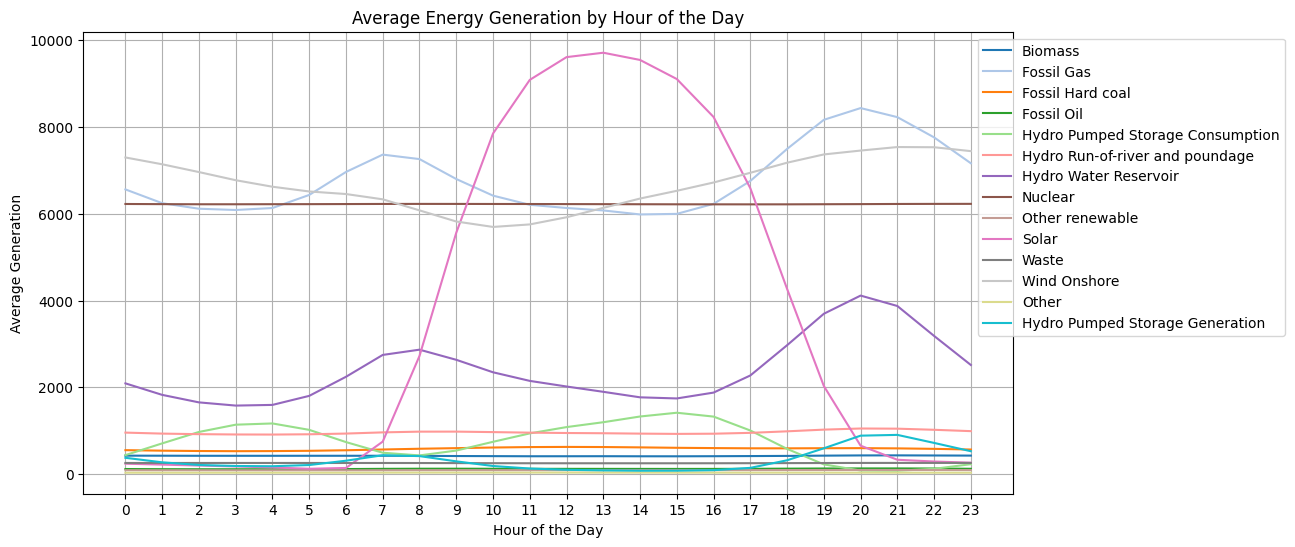

In [6]:
# Group by hour and calculate the average for each energy type
hourly_avg = generation_df.groupby(generation_df["datetime"].dt.hour)[generation_df.drop(columns ='datetime').columns].mean()

colours = [plt.colormaps["tab20"](i / 14) for i in range(14)]

plt.figure(figsize=(12, 6))
for i, source in enumerate(generation_df.drop(columns ='datetime').columns):
    plt.plot(hourly_avg.index, hourly_avg[source], color=colours[i], label=source)

plt.xlabel("Hour of the Day")
plt.ylabel("Average Generation")
plt.title("Average Energy Generation by Hour of the Day")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1)) 
plt.grid(True)
plt.xticks(range(24)) 
plt.show()

The graph above illustrates that the primary sources of energy in the Spanish market are solar, onshore wind, fossil gas, nuclear, and, to a lesser extent, hydro water reservoirs. Solar and wind production fluctuate throughout the day due to uncontrollable weather conditions, while fossil gas and hydro water reservoirs adjust with peaks between 7 AM–9 AM and 7 PM–9 PM to accommodate demand. Other energy sources either contribute significantly less to total generation or maintain more consistent output throughout the day, making them less critical for modeling.

Hydro pumped storage exhibits a distinct pattern, where excess energy is utilized between 1 AM–5 AM and 12 PM–4 PM to pump water uphill. This stored potential energy is then released during peak periods as hydro pumped storage generation to help meet demand.

Combining all data into a single dataframe:

In [7]:
# Energy Price Data
df_combined = pd.read_csv('data/energyPrice.csv')
df_combined['datetime'] = pd.to_datetime(df_combined['datetime'], errors='coerce')

# Weather Data
weather_dfs = {name: group.reset_index(drop=True).set_index('datetime') for name, group in weather_df.groupby('name')}

for df in weather_dfs.values():
    city = df['name'].unique()
    city_str = str(city).split(',')[0].strip().lower().replace('è', 'e').replace("['", '')
    df = df.add_suffix('_{}'.format(city_str))
    df_combined = df_combined.merge(df, on=['datetime'], how='outer')
    df_combined = df_combined.drop([f'name_{city_str}', f'index_{city_str}'], axis=1)

# Energy Generation Data
df_combined = df_combined.merge(generation_df, on=['datetime'], how='outer')
print(df_combined.shape)

# Energy Demand Data
actual_demand_df = pd.read_csv('data/actualTotalLoad.csv', parse_dates=['datetime'])
df_combined = df_combined.merge(actual_demand_df, on=['datetime'], how='outer')
predicted_demand_df = pd.read_csv('data/predictedDemand.csv', parse_dates=['datetime'])
df_combined = df_combined.merge(predicted_demand_df, on=['datetime'], how='outer')

df_combined.set_index('datetime', inplace=True)

# Public Holidays Data
holidays_df = pd.read_csv('data/national_holidays.csv', parse_dates=['date'])
holidays_list = holidays_df['date'].dt.date
df_combined['holiday_bool'] = pd.Series(df_combined.index.date, index=df_combined.index).isin(holidays_list).astype(int)

# Gas Price data
df_combined = df_combined.reset_index()
df_combined = df_combined.merge(
    gas_df[['Trading day', 'MIBGAS Daily Price [EUR/MWh]']], 
    left_on=df_combined['datetime'].dt.date, 
    right_on='Trading day', 
    how='left'
)
df_combined.set_index('datetime', inplace=True)
df_combined.drop(columns=['Trading day'], inplace=True)


print(df_combined.columns)

# Save dataframe
# df_combined.to_csv('data/price_df.csv', index=True)

(43849, 91)
Index(['Energy Price (EUR/MWh)', 'temp_barcelona', 'feelslike_barcelona',
       'dew_barcelona', 'humidity_barcelona', 'precip_barcelona',
       'precipprob_barcelona', 'snow_barcelona', 'snowdepth_barcelona',
       'windgust_barcelona', 'windspeed_barcelona', 'winddir_barcelona',
       'sealevelpressure_barcelona', 'cloudcover_barcelona',
       'visibility_barcelona', 'solarradiation_barcelona', 'temp_bilbao',
       'feelslike_bilbao', 'dew_bilbao', 'humidity_bilbao', 'precip_bilbao',
       'precipprob_bilbao', 'snow_bilbao', 'snowdepth_bilbao',
       'windgust_bilbao', 'windspeed_bilbao', 'winddir_bilbao',
       'sealevelpressure_bilbao', 'cloudcover_bilbao', 'visibility_bilbao',
       'solarradiation_bilbao', 'temp_madrid', 'feelslike_madrid',
       'dew_madrid', 'humidity_madrid', 'precip_madrid', 'precipprob_madrid',
       'snow_madrid', 'snowdepth_madrid', 'windgust_madrid',
       'windspeed_madrid', 'winddir_madrid', 'sealevelpressure_madrid',
       'cl

## Feature Engineering

The objective is to select features that can account for some of the variance in energy prices. Since energy prices are primarily influenced by energy generation, it is beneficial to identify features that can assist in predicting the generation levels of major energy sources (e.g., solar, wind, hydro, fossil gas). These features exhibit high variability, making them more impactful, whereas energy sources like nuclear remain highly consistent in their generation quantities.

A Pearson Correlation Matrix is used to determine relationships between variables, revealing that solar generation is strongly correlated with solar radiation, wind generation is correlated with wind speed and sea level pressure, and so on. These correlations serve as the foundation for selecting the initial features.

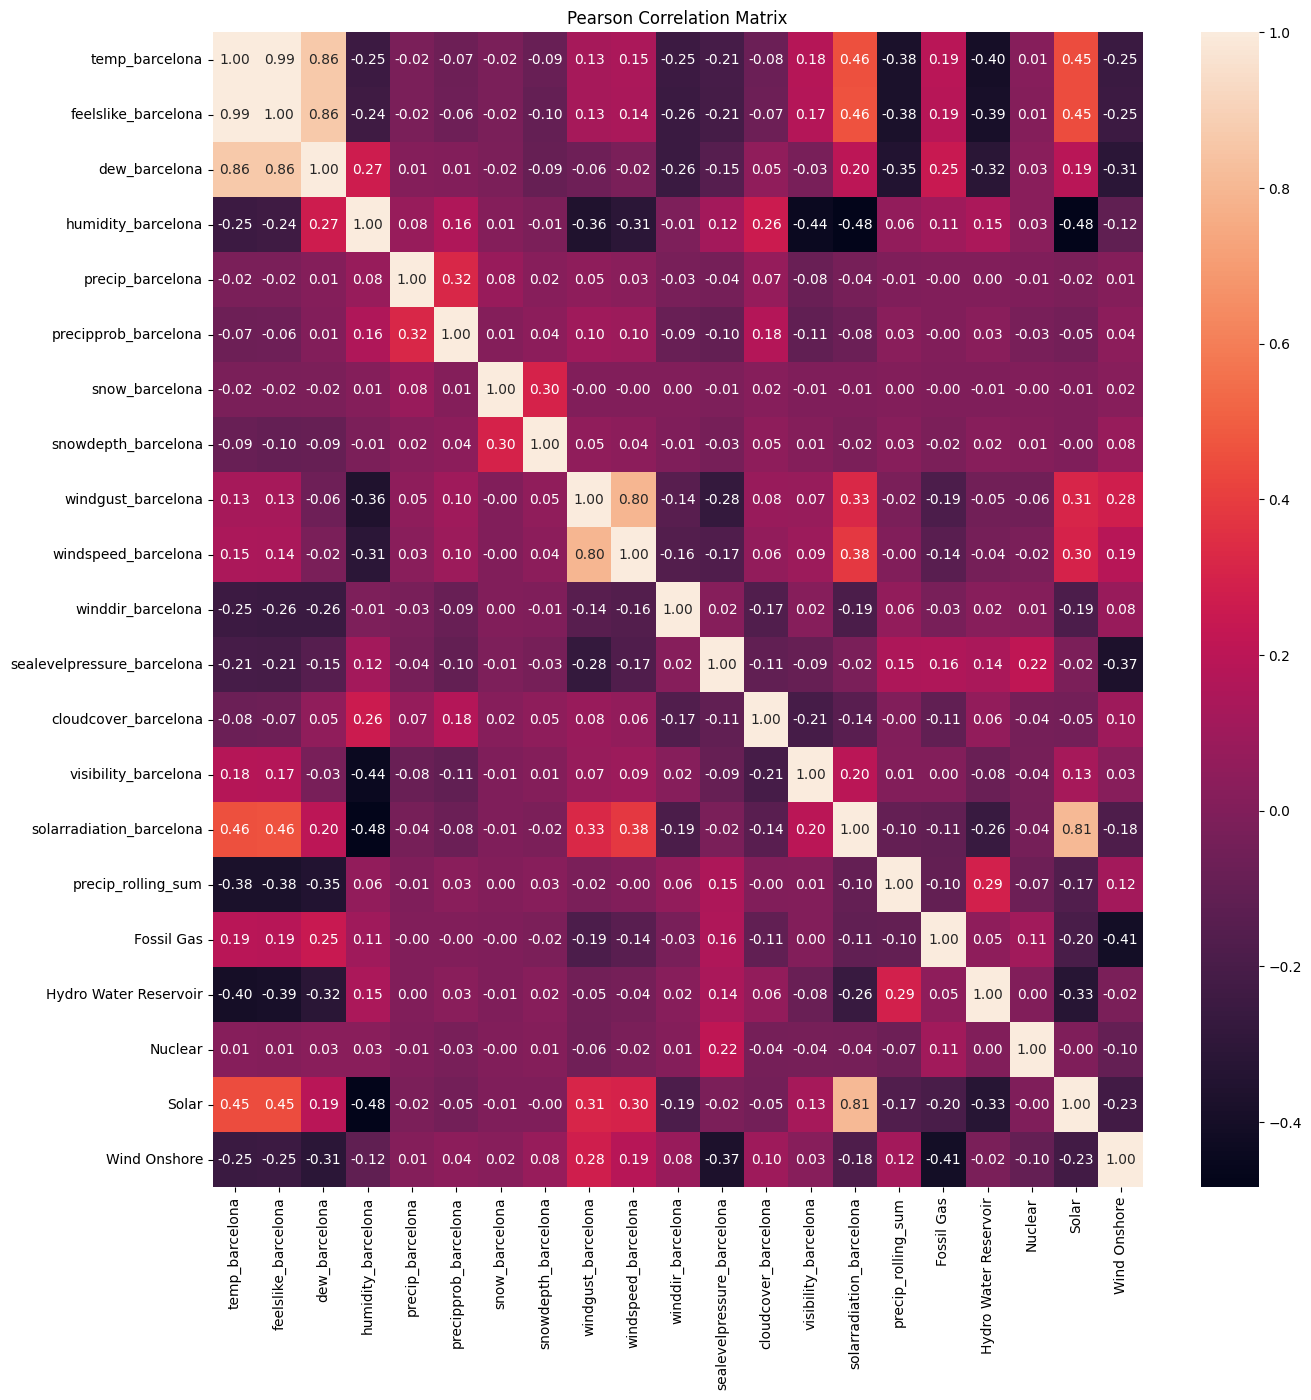

In [8]:
df_combined['precip_rolling_sum'] = df_combined['precip_madrid'].rolling(window=24*110, min_periods=1).sum()
correlations = df_combined[['temp_barcelona', 'feelslike_barcelona',
        'dew_barcelona', 'humidity_barcelona', 'precip_barcelona',
        'precipprob_barcelona', 'snow_barcelona', 'snowdepth_barcelona',
        'windgust_barcelona', 'windspeed_barcelona', 'winddir_barcelona',
        'sealevelpressure_barcelona', 'cloudcover_barcelona',
        'visibility_barcelona', 'solarradiation_barcelona', 'precip_rolling_sum',
        'Fossil Gas', 'Hydro Water Reservoir', 'Nuclear', 'Solar',
        'Wind Onshore']].corr(method='pearson')
fig = plt.figure(figsize=(15, 15))
sns.heatmap(correlations, annot=True, fmt='.2f')
plt.title('Pearson Correlation Matrix')
plt.show()
df_combined.drop(columns=['precip_rolling_sum'], inplace=True)

Since weather data is available for five cities, using all weather features individually is impractical, as it would result in an excessive number of features.

To address this, a weighted average of the weather data from the five cities will be used instead of individual city data. The weights will be determined based on the energy generation capacity of each energy type closest to each city. A Voronoi diagram will be constructed with nodes at the city locations to define the regions associated with each city’s energy generation.

In the graph below, larger dots indicate power plants with greater capacity.

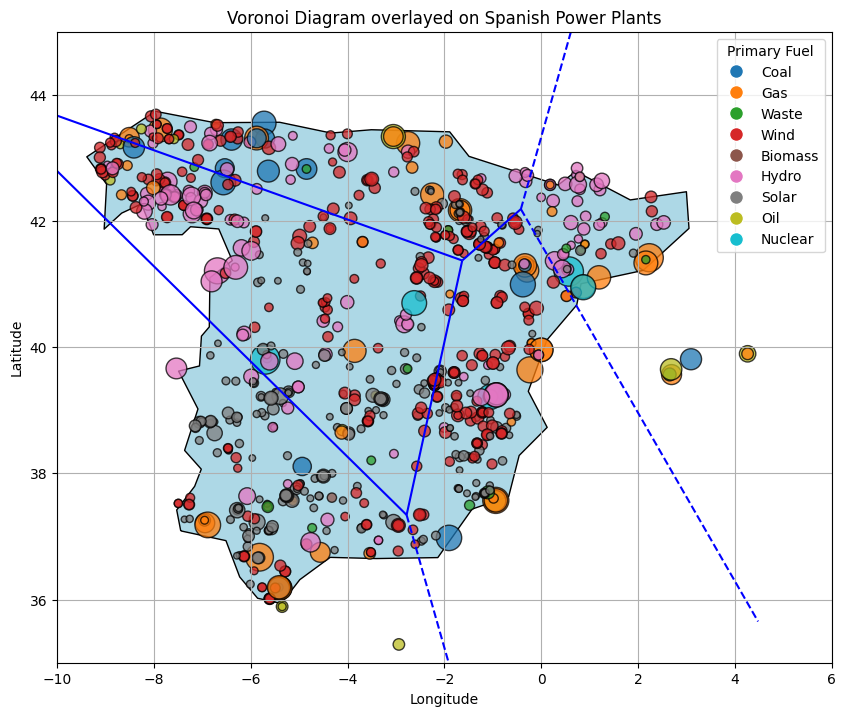

In [9]:
df = pd.read_csv('data/powerPlantDatabase.csv')

shapefile_path = 'data/country_shapes/ne_110m_admin_0_countries.shp'
world = gpd.read_file(shapefile_path)
spain = world[world['NAME'] == 'Spain']

# Define the coordinates of the 5 major cities
major_cities = {
    'Madrid': (-3.7033, 40.4169),
    'Barcelona': (2.1769, 41.3828),
    'Valencia': (-0.3764, 39.4700),
    'Sevilla': (-5.9900, 37.3900),
    'Bilbao': (-2.9236, 43.2569)
}
city_coords = np.array(list(major_cities.values()))

vor = Voronoi(city_coords)

fig, ax = plt.subplots(figsize=(10, 10))

spain.plot(ax=ax, color='lightblue', edgecolor='black')

size_factor = 10
sizes = np.sqrt(df['capacity_mw']) * size_factor

# Assign unique colors for each fuel type
fuel_types = df['primary_fuel'].unique()
color_map = {fuel: i for i, fuel in enumerate(fuel_types)}
colors = [color_map[fuel] for fuel in df['primary_fuel']]

cmap = plt.cm.get_cmap('tab10', len(fuel_types))
scatter = ax.scatter(df['longitude'], df['latitude'], c=colors, cmap=cmap, s=sizes, edgecolor='k', alpha=0.75)
handles = [plt.Line2D([0], [0], marker='o', color='w', markersize=10, markerfacecolor=cmap(i)) for i in range(len(fuel_types))]
ax.legend(handles, fuel_types, title="Primary Fuel", loc="upper right")

voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='blue', line_width=1.5, point_size=0)

ax.set_xlim(-10, 6)  # Spain's longitude range
ax.set_ylim(35, 45)  # Spain's latitude range

plt.title("Voronoi Diagram overlayed on Spanish Power Plants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

The solar, wind, and hydro energy generation capacities for each region are calculated and then normalized to sum to 1, allowing the relative weights for each region to be determined.

As shown, hydro generation is concentrated primarily in the Madrid region, solar generation is predominant in the Sevilla region, and wind energy is more evenly distributed across regions.

In [10]:
# Create a rectangle surrounding spain then a large rectangle surrounding it
polygon = shapely.wkt.loads('Polygon ((-10 35, -10 45, 6 45, 6 35, -10 35)))')
bound = polygon.buffer(20).envelope.boundary 

# Create many points along the rectangle boundary so Voroni regions don't go to infinity
boundarypoints = [bound.interpolate(distance=d) for d in range(0, np.ceil(bound.length).astype(int), 4)]
boundarycoords = np.array([[p.x, p.y] for p in boundarypoints])

#Create an array of all points on the boundary and inside the polygon
all_coords = np.concatenate((boundarycoords, city_coords)) 

vor = Voronoi(all_coords)

lines = [shapely.geometry.LineString(vor.vertices[line]) for line in 
    vor.ridge_vertices if -1 not in line]

polys = shapely.ops.polygonize(lines)
voronois = gpd.GeoDataFrame(geometry=gpd.GeoSeries(polys), crs="epsg:3006")

polydf = gpd.GeoDataFrame(geometry=[polygon], crs="epsg:3006")
points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(x=city_coords[:,0], y=city_coords[:,1], crs="epsg:3006"))

result = gpd.overlay(df1=voronois, df2=polydf, how="intersection")
result['region_id'] = range(len(result))
city_labels = {
    3: 'Madrid',
    0: 'Barcelona',
    2: 'Valencia',
    4: 'Sevilla',
    1: 'Bilbao'
}

# Add a column for city labels based on region ID
result['city'] = result['region_id'].map(city_labels)

powerplants_gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']), crs='epsg:3006'
)

# Perform spatial join
powerplants_gdf = gpd.sjoin(powerplants_gdf, result, how='inner', predicate='within')

# Sum population density within each Voronoi region
solar_sum = powerplants_gdf.loc[powerplants_gdf['primary_fuel'] == 'Solar'].groupby('city')['capacity_mw'].sum()
wind_sum = powerplants_gdf.loc[powerplants_gdf['primary_fuel'] == 'Wind'].groupby('city')['capacity_mw'].sum()
hydro_sum = powerplants_gdf.loc[powerplants_gdf['primary_fuel'] == 'Hydro'].groupby('city')['capacity_mw'].sum()

# Normalize so that the total population density sums to 1
solar_sum_normalized = solar_sum / solar_sum.sum()
wind_sum_normalized = wind_sum / wind_sum.sum()
hydro_sum_normalized = hydro_sum / hydro_sum.sum()

print(f'Solar Energy Split : \n{solar_sum_normalized}\n')
print(f'Wind Energy Split : \n{wind_sum_normalized}\n')
print(f'Hydro Energy Split : \n{hydro_sum_normalized}')

Solar Energy Split : 
city
Barcelona    0.011677
Bilbao       0.039911
Madrid       0.239902
Sevilla      0.585001
Valencia     0.123509
Name: capacity_mw, dtype: float64

Wind Energy Split : 
city
Barcelona    0.023246
Bilbao       0.236938
Madrid       0.335746
Sevilla      0.103898
Valencia     0.300172
Name: capacity_mw, dtype: float64

Hydro Energy Split : 
city
Barcelona    0.135433
Bilbao       0.101462
Madrid       0.481331
Sevilla      0.089994
Valencia     0.191780
Name: capacity_mw, dtype: float64


### Creating the Dataframe

Weighted weather features are generated based on the weather variables that exhibit strong correlations with specific energy generation types.

In [11]:
def calculateWeightedHourlyData(city_weights, column_prefix, master_df, weighted_results):
    weighted_sums = {hour: pd.Series(0, index=weighted_results.index, dtype=float) for hour in range(24)}

    for city, weight in city_weights.items():
        daily_data = master_df.pivot(index='date', columns='hour', values=f'{column_prefix}_{city.lower()}')
        
        for hour in range(24):
            weighted_sums[hour] += daily_data[hour] * weight

    for hour in range(24):
        weighted_results[f'{column_prefix}_weighted_{hour}'] = weighted_sums[hour]
    
    return weighted_results

def calculateWeightedMinMaxMeanData(city_weights, column_prefix, master_df, weighted_results):
    for metric in ['mean', 'min', 'max']:
        weighted_sum = pd.Series(0, index=weighted_results.index, dtype=float)

        for city, weight in city_weights.items():
            column_name = f'{column_prefix}_{city.lower()}'
            if column_name in master_df.columns:
                daily_metric = master_df.groupby('date')[column_name].agg(metric)
                weighted_sum += daily_metric * weight
            
            weighted_results[f'{column_prefix}_weighted_daily_{metric}'] = weighted_sum
    
    return weighted_results

def calculateWeightedRollingSum(city_weights, column_prefix, master_df, weighted_results, window_hours):
    weighted_precip = pd.Series(0, index=weighted_results.index, dtype=float)

    for city, weight in city_weights.items():
        city_precip_col = f'{column_prefix}_{city.lower()}'
        if city_precip_col in master_df.columns:
            rolling_sum = master_df[city_precip_col].rolling(window=window_hours, min_periods=1).sum()
            weighted_precip += rolling_sum * weight

    weighted_results[f'precip_rolling_sum_{int(window_hours/24)}_days'] = weighted_precip
    return weighted_results


# Extract the date and hour
df_combined['date'] = df_combined.index.to_series().dt.date
df_combined['hour'] = df_combined.index.to_series().dt.hour

# Initialize a DataFrame
weighted_results = pd.DataFrame(index=pd.to_datetime(df_combined['date'].unique())) 


# Create weighted weather features
weighted_results = calculateWeightedHourlyData(solar_sum_normalized, 'solarradiation', df_combined, weighted_results)
weighted_results = calculateWeightedMinMaxMeanData(solar_sum_normalized, 'solarradiation', df_combined, weighted_results)
weighted_results = calculateWeightedMinMaxMeanData(solar_sum_normalized, 'temp', df_combined, weighted_results)
weighted_results = calculateWeightedMinMaxMeanData(solar_sum_normalized, 'humidity', df_combined, weighted_results)
weighted_results = calculateWeightedHourlyData(wind_sum_normalized, 'windspeed', df_combined, weighted_results)
weighted_results = calculateWeightedMinMaxMeanData(wind_sum_normalized, 'windgust', df_combined, weighted_results)
weighted_results = calculateWeightedMinMaxMeanData(wind_sum_normalized, 'winddir', df_combined, weighted_results)
weighted_results = calculateWeightedMinMaxMeanData(wind_sum_normalized, 'sealevelpressure', df_combined, weighted_results)
weighted_results = calculateWeightedMinMaxMeanData(hydro_sum_normalized, 'precip', df_combined, weighted_results)

# Remove solarradiation columns which are almost always zero (ie night)
for i in range(24):
    non_zero_count = (weighted_results[f'solarradiation_weighted_{i}'] != 0).sum()
    if non_zero_count < 40:
        weighted_results.drop(columns=[f'solarradiation_weighted_{i}'], inplace=True)

# Create rolling sum weighted hydro weather features
weighted_results = calculateWeightedRollingSum(hydro_sum_normalized, 'precip', df_combined, weighted_results, 24*30)
weighted_results = calculateWeightedRollingSum(hydro_sum_normalized, 'precip', df_combined, weighted_results, 24*60)
weighted_results = calculateWeightedRollingSum(hydro_sum_normalized, 'precip', df_combined, weighted_results, 24*110)

weighted_results = weighted_results.round(2)


# Shifted Energy Generation Data
energy_types = ['Fossil Gas', 'Hydro Water Reservoir', 'Solar', 'Wind Onshore']
for energy in energy_types:
    df_combined[f"day_shifted_{energy.replace(' ', '_').lower()}"] = df_combined[energy].shift(36)
    energy_data = df_combined.pivot(index='date', columns='hour', values=f"day_shifted_{energy.replace(' ', '_').lower()}")
    ordered_columns = list(range(12, 24)) + list(range(0, 12))
    energy_data.columns = [f"{energy.replace(' ', '_').lower()}_day_delay_{hour}" for hour in ordered_columns]
    weighted_results = weighted_results.merge(energy_data, left_index=True, right_index=True)

other_energy_types = ['Biomass', 'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage Consumption', 
                        'Hydro Run-of-river and poundage', 'Nuclear', 'Other renewable', 'Waste',
                        'Other', 'Hydro Pumped Storage Generation']

for energy in other_energy_types:
    for metric in ['mean', 'min', 'max']:
        weighted_results[f"{energy.replace(' ', '_').lower()}_{metric}"] = df_combined[energy].shift(36).groupby(df_combined['date']).agg(metric)


# National Holiday Data
dates_df = pd.read_csv('data/national_holidays.csv', parse_dates=['date'])
dates_list = dates_df['date'].dt.date
weighted_results['holiday_bool'] = weighted_results.index.isin(dates_list).astype(int)

# Time features
weighted_results['day_of_week'] = weighted_results.index.dayofweek  # 0=Monday, 6=Sunday
weighted_results['month'] = weighted_results.index.month            # 1=January, 12=December
weighted_results['year'] = weighted_results.index.year - 2018

# Cyclical encoding of features for day_of_week and month
weighted_results['day_of_week_sin'] = np.sin(2 * np.pi * weighted_results['day_of_week'] / 7)
weighted_results['day_of_week_cos'] = np.cos(2 * np.pi * weighted_results['day_of_week'] / 7)
weighted_results['month_sin'] = np.sin(2 * np.pi * weighted_results['month'] / 12)
weighted_results['month_cos'] = np.cos(2 * np.pi * weighted_results['month'] / 12)

# Create weekend_bool column (True if Saturday or Sunday)
weighted_results['weekend_bool'] = (weighted_results['day_of_week'] >= 5).astype(int)

weighted_results.drop(['day_of_week', 'month'], axis=1, inplace=True)


# Shifted Price Data
df_combined['day_shifted_price'] = df_combined['Energy Price (EUR/MWh)'].shift(36)
df_combined['week_shifted_price'] = df_combined['Energy Price (EUR/MWh)'].shift(168)

# Now pivot the shifted price data to get 24 hours of price for each day
price_data = df_combined.pivot(index='date', columns='hour', values=['day_shifted_price', 'week_shifted_price'])

# Optionally rename columns for clarity
ordered_columns = list(range(12, 24)) + list(range(0, 12))

# Rename the columns with the desired names (Demand_Hour_12, ..., Demand_Hour_11)
price_data.columns = [f'price_day_delay_{hour}' for hour in ordered_columns] + [f'price_week_delay_{hour}' for hour in range(24)]

# Merge the price data into the daily data
weighted_results = weighted_results.merge(price_data, left_index=True, right_index=True)


# Shifted Gas Price Data
gas_df = pd.read_csv('data/gasPriceData.csv', parse_dates=['Trading day'])
dates_list = gas_df['Trading day'].dt.date
weighted_results['gas_price'] = weighted_results.index.isin(dates_list).astype(int)
weighted_results['gas_price_day_delay'] = weighted_results['gas_price'].shift(1)
weighted_results.drop(['gas_price'], axis=1, inplace=True)


# Predicted Demand values
target_data = (
    df_combined.groupby('date')['predicted_demand']
    .apply(lambda group: group.reset_index(drop=True).to_list())
    .to_frame(name='predicted_demand')
)
predicted_demand_expanded = target_data['predicted_demand'].apply(pd.Series)
predicted_demand_expanded.columns = [f'predicted_demand_{i}' for i in range(24)]
weighted_results = weighted_results.merge(predicted_demand_expanded, left_index=True, right_index=True)

# Shifted Demand values
target_data = (
    df_combined.shift(36).groupby('date')['Actual Total Load (MW)']
    .apply(lambda group: group.reset_index(drop=True).to_list())
    .to_frame(name='shifted_demand')
)
shifted_demand_expanded = target_data['shifted_demand'].apply(pd.Series)
shifted_demand_expanded.columns = [f'shifted_demand_{i}' for i in range(24)]
weighted_results = weighted_results.merge(shifted_demand_expanded, left_index=True, right_index=True)


# Target values
target_data = (
    df_combined.groupby('date')['Energy Price (EUR/MWh)']
    .apply(lambda group: group.reset_index(drop=True).to_list())
    .to_frame(name='actual_price')
)
weighted_results = weighted_results.merge(target_data, left_index=True, right_index=True)


# Remove incomplete rows with NaNs
weighted_results = weighted_results.iloc[7:-1]

print(weighted_results.shape)
print(weighted_results.columns)

(1818, 297)
Index(['solarradiation_weighted_6', 'solarradiation_weighted_7',
       'solarradiation_weighted_8', 'solarradiation_weighted_9',
       'solarradiation_weighted_10', 'solarradiation_weighted_11',
       'solarradiation_weighted_12', 'solarradiation_weighted_13',
       'solarradiation_weighted_14', 'solarradiation_weighted_15',
       ...
       'shifted_demand_15', 'shifted_demand_16', 'shifted_demand_17',
       'shifted_demand_18', 'shifted_demand_19', 'shifted_demand_20',
       'shifted_demand_21', 'shifted_demand_22', 'shifted_demand_23',
       'actual_price'],
      dtype='object', length=297)


## Feature Selection

To ensure robust model training, the general guideline of maintaining at least 10 times more data points than features is followed. The training dataset consists of 1,461 days, meaning a maximum of 146 features can be used to maintain the 10:1 ratio.

Currently, the dataframe contains 296 features, which significantly exceeds this threshold.

Principal Component Analysis (PCA) could be applied to reduce dimensionality; however, this approach reduces model interpretability, as features are combined, making it difficult to directly attribute performance to individual original features.

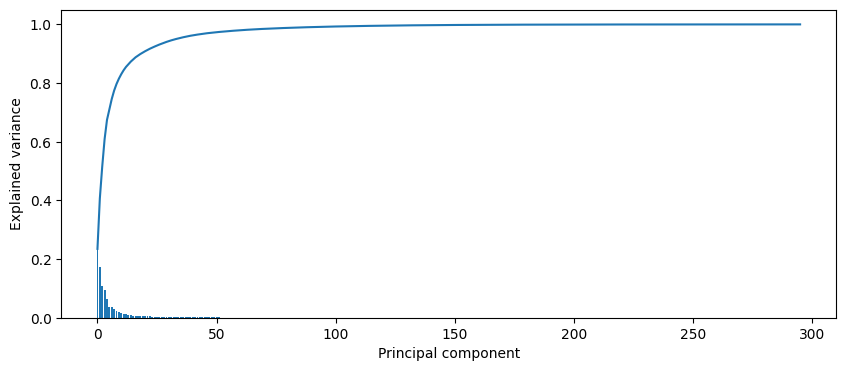

In [12]:
X = weighted_results.drop(columns=['actual_price'])
y = np.vstack(weighted_results['actual_price'])

# Normalise the data between 0 and 1
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_norm = scaler_X.fit_transform(X)
y_norm = scaler_y.fit_transform(y)

pca = PCA()
X_pca = pca.fit(X_norm)

num_components = len(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 4))
plt.bar(np.arange(num_components), pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Principal component')
plt.ylabel('Explained variance')
plt.show()

We want an 20:80 test:train data split. This results in the last year of data being used for testing. Since the dataset contains lagged features, a random train-test split would cause data leakage, as future values could unintentionally influence past predictions. Instead, the split must be sequential to ensure the model only learns from past data and generalizes correctly to future, unseen data.

Test data will only be used as a final test, not as part of the feature selection process.

In [13]:
# 80% train, 20% test
X_train = X_norm[:1456]
y_train = y_norm[:1456]
X_test = X_norm[1456:]
y_test = y_norm[1456:]

**SHAP** (SHapley Additive exPlanations) is used to quantify the contribution of each feature to the model’s predictions. This information helps identify and remove features that have little or even negative impact on performance.

In the process below, features are grouped (e.g., all wind speed features are combined), and the average SHAP value for each group is calculated. The model is then iteratively retrained using **cross-validation** to assess whether each feature group improves performance. If a group does not contribute positively, it is removed.

The pruning process starts with the highest SHAP value groups and progresses downward. Since the dataset contains highly correlated features, removing dominant ones first helps evaluate the true importance of others. This also reveals whether the model is overly reliant on a few influential but potentially noisy features.

After completing this process, only 138 features remain, and the model's performance improves, achieving the desired 10:1 data points-to-features ratio.

In [14]:
params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 4,
    "learning_rate": 0.1,
    "n_estimators": 100,
}

base_model = XGBRegressor(**params)
multioutput_model = MultiOutputRegressor(base_model)

multioutput_model.fit(X_train, y_train)

all_shap_values = []

# For each model in the MultiOutputRegressor, apply SHAP
for i, model in enumerate(multioutput_model.estimators_):
    explainer = shap.TreeExplainer(model)
    
    shap_values = explainer.shap_values(X_train)
    
    all_shap_values.append(shap_values)

all_shap_values = np.array(all_shap_values)
mean_shap_values = np.mean(all_shap_values, axis=0)

feature_names = weighted_results.columns[:-1].to_list()

# Get mean absolute SHAP values per feature
shap_importance = np.abs(mean_shap_values).mean(axis=0)
modified_elements = [f.rsplit('_', 1)[0] for f in feature_names]

# Get mean absolute SHAP values per feature group
prefix_importance = {}
for prefix, importance in zip(modified_elements, shap_importance):
    if prefix not in prefix_importance:
        prefix_importance[prefix] = []
    prefix_importance[prefix].append(importance)

for prefix in prefix_importance.keys():
    prefix_importance[prefix] = np.mean(prefix_importance[prefix])

sorted_prefix_importance = sorted(prefix_importance.items(), key=lambda x: x[1], reverse=True)


# Successive Feature Removal
best_rmse = float("inf")
best_features = feature_names.copy()
for i in range(len(sorted_prefix_importance) + 1):
    reduced_features = best_features.copy()
    if i > 0:
        prefix = sorted_prefix_importance[i - 1][0]  # Get the prefix from sorted list
        features_to_test = []
        for feature in feature_names:
            if feature.rsplit('_', 1)[0] == prefix:
                features_to_test.append(feature)
        # Delete the features from reduced_features list
        for feature in features_to_test:
            reduced_features.remove(feature)


    # Filter feature indices
    selected_indices = [feature_names.index(f) for f in reduced_features]
    X_train_reduced = X_train[:, selected_indices]

    # Retrain model
    base_model = XGBRegressor(**params)
    multioutput_model = MultiOutputRegressor(base_model)

    # Cross Validation
    rmse_scores = cross_val_score(multioutput_model, X_train_reduced, y_train, 
                                scoring='neg_root_mean_squared_error', cv=5)
    mean_rmse = -np.mean(rmse_scores).round(4)

    if i > 0:
        print(f"Features Tested: {features_to_test}")
        print(f"Features Tested: {i}/{len(sorted_prefix_importance)}, Remaining Features: {len(reduced_features)}, RMSE: {mean_rmse}")
    else:
        print(f"Features Tested: {i}, Remaining Features: {len(reduced_features)}, RMSE: {mean_rmse}")

    if mean_rmse <= best_rmse or prefix == "predicted_demand":
        if i > 0:
            print(f'Features Removed, RMSE <= Best RMSE : {best_rmse}')
            for feature in features_to_test:
                best_features.remove(feature)
        best_rmse = mean_rmse
    else:
        print(f'Features Kept, RMSE > Best RMSE : {best_rmse}')
    print('---------------------------')

print("\nBest feature subset:", best_features)

Features Tested: 0, Remaining Features: 296, RMSE: 0.0517
---------------------------
Features Tested: ['price_day_delay_12', 'price_day_delay_13', 'price_day_delay_14', 'price_day_delay_15', 'price_day_delay_16', 'price_day_delay_17', 'price_day_delay_18', 'price_day_delay_19', 'price_day_delay_20', 'price_day_delay_21', 'price_day_delay_22', 'price_day_delay_23', 'price_day_delay_0', 'price_day_delay_1', 'price_day_delay_2', 'price_day_delay_3', 'price_day_delay_4', 'price_day_delay_5', 'price_day_delay_6', 'price_day_delay_7', 'price_day_delay_8', 'price_day_delay_9', 'price_day_delay_10', 'price_day_delay_11']
Features Tested: 1/36, Remaining Features: 272, RMSE: 0.0709
Features Kept, RMSE > Best RMSE : 0.0517
---------------------------
Features Tested: ['windgust_weighted_daily_mean', 'windgust_weighted_daily_min', 'windgust_weighted_daily_max']
Features Tested: 2/36, Remaining Features: 293, RMSE: 0.0519
Features Kept, RMSE > Best RMSE : 0.0517
---------------------------
Featur

## XGBoost Model Training & Evaluation

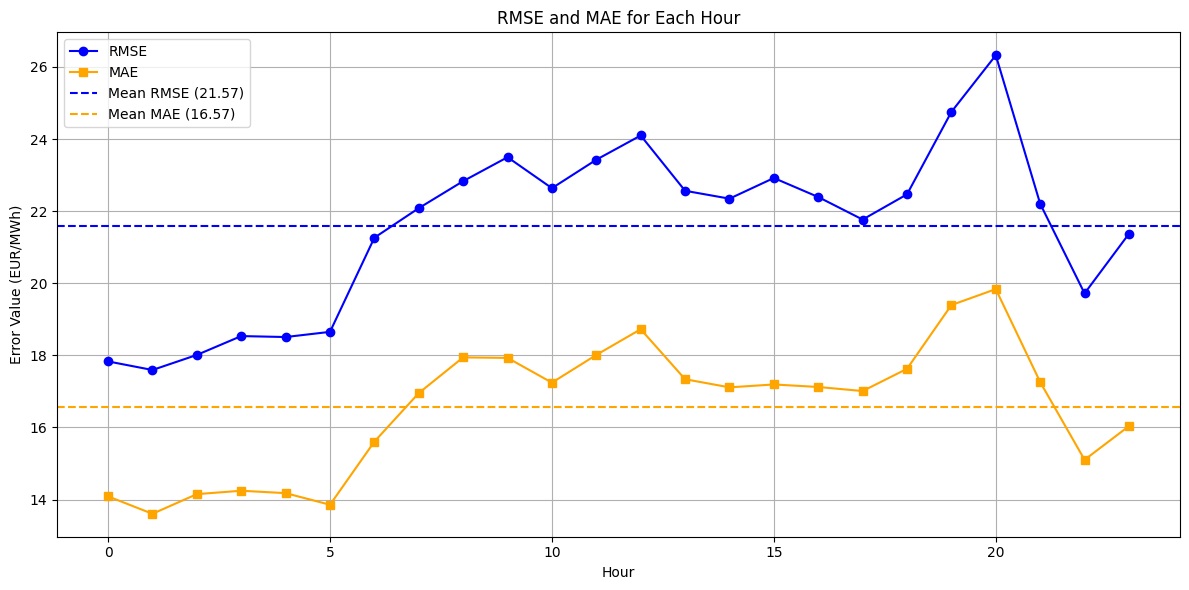

In [15]:
selected_indices = [feature_names.index(f) for f in best_features]
X_train_reduced = X_train[:, selected_indices]
X_test_reduced = X_test[:, selected_indices]

params = {
        'eta': 0.04,                  # Learning rate; controls the step size during optimization.
        'max_depth': 4,               # Maximum depth of a tree; prevents overfitting and controls model complexity.
        'n_estimators': 700,          # Total number of boosting iterations (trees) to build.
        'subsample': 0.7,             # Fraction of training data used for each tree; reduces overfitting.
        'colsample_bytree': 0.8,      # Fraction of features used for each tree; reduces overfitting.
        'alpha': 0,                   # L1 regularization term on weights; controls model sparsity.
        'lambda': 0.15,               # L2 regularization term on weights; prevents overfitting.
        'gamma': 0,                   # Minimum loss reduction required for a split; controls tree pruning.
        'objective': 'reg:squarederror',  # Specifies the task to solve; here, regression using squared error loss.
        'eval_metric': 'rmse',        # Evaluation metric; calculates root mean squared error for validation.
        'min_child_weight': 10,       # Minimum sum of instance weights (hessian) in a child; controls overfitting.
        'booster': 'gbtree',          # Model type; uses tree-based boosting.
        'n_jobs': -1                  # Number of parallel threads; -1 uses all available CPU cores.
}

# Initialize XGBoost model with parameters
base_model = XGBRegressor(**params)
multioutput_model = MultiOutputRegressor(base_model)

# Fit the model
multioutput_model.fit(X_train_reduced, y_train)

# Predict
y_pred = multioutput_model.predict(X_test_reduced)
y_pred = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred, multioutput='raw_values'))
mae = mean_absolute_error(y_test_inv, y_pred, multioutput='raw_values')
mean_rmse = np.mean(rmse)
mean_mae = np.mean(mae)

plt.figure(figsize=(12, 6))
plt.plot(rmse, label='RMSE', marker='o', linestyle='-', color='blue')
plt.plot(mae, label='MAE', marker='s', linestyle='-', color='orange')
plt.axhline(mean_rmse, color='blue', linestyle='--', label=f'Mean RMSE ({mean_rmse:.2f})')
plt.axhline(mean_mae, color='orange', linestyle='--', label=f'Mean MAE ({mean_mae:.2f})')

plt.title('RMSE and MAE for Each Hour')
plt.xlabel('Hour')
plt.ylabel('Error Value (EUR/MWh)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
# Save the trained model
joblib.dump(multioutput_model, "models/price_xgboost_model.pkl")

['models/price_xgboost_model.pkl']

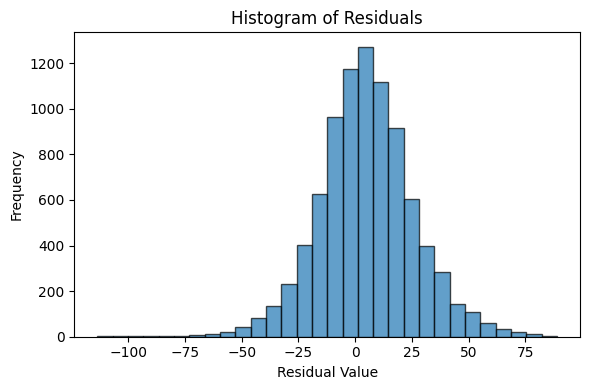

In [17]:
y_errors = y_pred-y_test_inv
y_errors_flattened = y_errors.flatten()

plt.figure(figsize=(6, 4))
plt.hist(y_errors_flattened, bins=30, edgecolor="k", alpha=0.7)
plt.title("Histogram of Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Summary

The XGBoost model significantly outperformed the benchmark model in predicting energy demand. It achieved a Root Mean Squared Error (RMSE) of 21.57 EUR/MWh, and a Mean Absolute Error (MAE) of 16.57 EUR/MWh, compared to the benchmark RMSE of 30.70 EUR/MWh, MAE of 21.16 EUR/MWh. This represents a substantial 22 - 29% reduction in error, demonstrating the model's ability to capture complex patterns in the data.

One key factor contributing to this improvement is the use of additional explanatory variables beyond just actual price. Incorporating external factors such as weather conditions, energy generation data, and other relevant predictors helped explain more variance in energy consumption.